In [1]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt

# Advanced signal pro cessing - Multirate signal pro cessing

## 1 Upsampling with linear interpolation
Consider a signal given by
$$
x[n] =
\begin{cases}
-1 & n=1 \\
3 & n=2 \\
0 & \text{elsewhere}
\end{cases}
$$

### 1. Upsample the signal using I = 4 and the linear interpolation kernel given by Eq. 12.48.

In [40]:
m = np.arange(4)
x = np.zeros(len(m))
x[m == 1] = -1
x[m == 2] = 3
x

array([ 0., -1.,  3.,  0.])

In [41]:
I = 4
x_upsampled = np.zeros(len(x) * I)
x_upsampled[::I] = x
x_upsampled

array([ 0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.])

In [42]:
n=np.arange(-I+1, I)
g_lin = 1 - np.abs(n) / I
g_lin

array([0.25, 0.5 , 0.75, 1.  , 0.75, 0.5 , 0.25])

In [43]:
y = np.convolve(x_upsampled, g_lin)
y

array([ 0.  ,  0.  ,  0.  ,  0.  , -0.25, -0.5 , -0.75, -1.  ,  0.  ,
        1.  ,  2.  ,  3.  ,  2.25,  1.5 ,  0.75,  0.  ,  0.  ,  0.  ,
        0.  ,  0.  ,  0.  ,  0.  ])

### 2. Sketch the signal before and after the upsampling and interpolation.

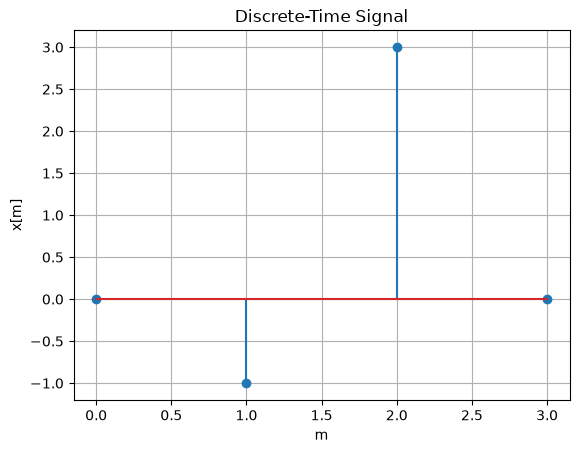

In [44]:
plt.stem(m, x)
plt.xlabel('m')
plt.ylabel('x[m]')
plt.title('Discrete-Time Signal')
plt.grid(True)
plt.show()

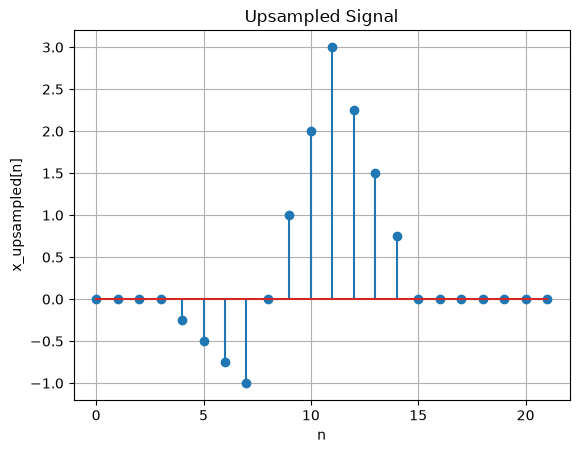

In [45]:
plt.stem(np.arange(len(y)), y)
plt.xlabel('n')
plt.ylabel('x_upsampled[n]')
plt.title('Upsampled Signal')
plt.grid(True)
plt.show()

## 2 Downsampling is a linear operation
In example 12.1* the authors state without proof that downsampling is a linear operation.

*it is 12.2

### 1. Show that downsampling is indeed a linear operation.

From example 2.4

> A *downsampler* is a system,
> $$
> \begin{equation}
> \tag{2.24}
> y[n] = \mathcal{H}\set{x[n]} = x[Mn]
> \end{equation}
> $$
> that is used to sample a discrete-time signal $x[n]$ by a factor of $M$.

> **Definition 2.3**
> 
> A system is called linear if and only if for every real or complex constant $a_1$, $a_2$ and every input signal $x_1[n]$ and $x_2[n]$
> 
> $$
> \begin{equation}
> \tag{2.19}
> \mathcal{H}\set{a_1x_1[n] + a_2x_2[n]} = a_1 \mathcal{H}\set{x_1[n]} + a_2 \mathcal{H}\set{x_2[n]}
> \end{equation}
> $$
> for all values of $n$.

To test linearity, let $y_1[n] = x_1[nM]$ and $y_2[n] = x_2[nM]$. Consider the downsampler output due to the input $x[n] = a_1x_1[n] + a_2x_2[n]$ given by
$$
\begin{align*}
y[n] &= \mathcal{H}\set{x[n]} = x[nM] = a_1x_1[nM] + a_2x_2[nM]\\
&= a_1y_1[n] + a_2y_2[n].
\end{align*}
$$
Hence the downsampler is linear.

## 3 Sample rate conversion
Explain the difference between downsampling, upsampling, decimation and interpolation.

Dowsampling is reducing the sampling rate of a signal. Upsampling is increasing the sampling rate of a signal.

Decimation is the process of downsampling by removing samples from a signal at an integer factor. Interpolation is the process of upsampling by inserting new samples between existing samples.

[Source](https://www.youtube.com/watch?v=g_12MFQFXLA)